## Data Story From CatBoost Model that predicts Smokers
 
### Pre-DataWrangling Steps to determine if we can use the current dataset to simulate various policy scenarios <br>

1. Perform SHAP analysis on our prior model (CatBoost Model) to find out the most impactful levers guiding prediction of smoking
2. Perform SHAP analysis across age group

Outcomes - <br>
1. Our previous model has NaNs encoded either as 7 or 9, which needs to be handled to plot informative SHAP plots
2. Fix the order/encoding for some of the Ordinal variables to generate meaningful results on our SHAP plots
3. Label encode our variables to help in SHAP plots

Lets, use our saved catboost model and perform SHAP analysis on it to find the crucial levers that can be simulated to bring about a positive change in smoking numbers

In [2]:
#pip install shap catboost

In [37]:
#import model from last notebook
from catboost import CatBoostClassifier
import shap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle


In [38]:
#load data
import pickle

# Replace '002-eda_final.pkl' with the actual filename if different
with open('../data/processed/002-eda_final.pkl', 'rb') as f:
    df_shap_analysis = pickle.load(f)

# Display the first few rows of the DataFrame to verify successful loading
df_shap_analysis.head()  # Display the first few rows of the DataFrame to verify successful

df_shap_analysis.columns # List all columns in the DataFrame

Index(['DISPCODE', 'GENHLTH', 'PHYSHLTH', 'MENTHLTH', 'HLTHPLN1', 'PERSDOC2',
       'MEDCOST', 'CHECKUP1', 'CVDINFR4', 'CVDCRHD4', 'CVDSTRK3', 'ASTHMA3',
       'CHCSCNCR', 'CHCOCNCR', 'CHCCOPD1', 'HAVARTH3', 'ADDEPEV2', 'CHCKIDNY',
       'DIABETE3', 'SEX', 'MARITAL', 'RENTHOM1', 'VETERAN3', 'CHILDREN',
       'WEIGHT2', 'HEIGHT3', 'QLACTLM2', 'USEEQUIP', 'EXERANY2', 'PNEUVAC3',
       'HIVTST6', '_RFHLTH', '_HCVU651', '_LTASTH1', '_CASTHM1', '_ASTHMS1',
       '_DRDXAR1', '_RFBMI5', '_CHLDCNT', '_EDUCAG', '_INCOMG', '_RFSMOK3',
       'DRNKANY5', '_RFBING5', '_TOTINDA', '_RFSEAT3', 'YEAR', 'DIABETES',
       '_AGE65YR'],
      dtype='object')

In [39]:
df_shap_analysis.head()

,DISPCODE,GENHLTH,PHYSHLTH,MENTHLTH,HLTHPLN1,PERSDOC2,MEDCOST,CHECKUP1,CVDINFR4,CVDCRHD4,...,_EDUCAG,_INCOMG,_RFSMOK3,DRNKANY5,_RFBING5,_TOTINDA,_RFSEAT3,YEAR,DIABETES,_AGE65YR
0,1200,5,3,4,1,1,2,1,2,2,...,2,2,0,2,1,2,1,2015,2,1
1,1100,3,1,1,2,1,1,4,2,2,...,4,1,1,2,1,1,2,2015,2,1
3,1100,5,4,4,1,2,1,1,2,2,...,2,5,0,2,1,2,1,2015,2,1
4,1100,5,4,1,1,1,2,1,2,2,...,3,5,0,2,1,2,1,2015,2,1
5,1100,2,1,1,1,1,2,1,2,2,...,1,4,0,2,1,1,1,2015,2,2


In [47]:
#load model_shap_analysis
from catboost import CatBoostClassifier
model_shap_analysis = CatBoostClassifier()
model_shap_analysis.load_model('../models/final_catboost_model_default.cbm')

# Check feature names
feature_names = model_shap_analysis.feature_names_



In [44]:
# Identify categorical features
cat_features = [col for col in X.columns if X[col].dtype == 'object'
                or X[col].dtype.name == 'category']

for col in cat_features:
    df_shap_analysis[col] = df_shap_analysis[col].astype(str).fillna('7')

# Prepare data for SHAP analysis
X = df_shap_analysis.drop(columns=['_RFSMOK3'])  # Features
y = df_shap_analysis['_RFSMOK3']  # Target variable

print(f"Categorical features for SHAP analysis: {cat_features}")


Categorical features for SHAP analysis: ['DISPCODE', 'GENHLTH', 'PHYSHLTH', 'MENTHLTH', 'HLTHPLN1', 'PERSDOC2', 'MEDCOST', 'CHECKUP1', 'CVDINFR4', 'CVDCRHD4', 'CVDSTRK3', 'ASTHMA3', 'CHCSCNCR', 'CHCOCNCR', 'CHCCOPD1', 'HAVARTH3', 'ADDEPEV2', 'CHCKIDNY', 'DIABETE3', 'SEX', 'MARITAL', 'RENTHOM1', 'VETERAN3', 'QLACTLM2', 'USEEQUIP', 'EXERANY2', 'PNEUVAC3', 'HIVTST6', '_RFHLTH', '_HCVU651', '_LTASTH1', '_CASTHM1', '_ASTHMS1', '_DRDXAR1', '_RFBMI5', '_CHLDCNT', '_EDUCAG', '_INCOMG', 'DRNKANY5', '_RFBING5', '_TOTINDA', '_RFSEAT3', 'YEAR', 'DIABETES', '_AGE65YR']


In [45]:
# drop _STATE column from cat_features if it exists
if '_STATE' in cat_features:
    cat_features.remove('_STATE')


In [50]:
from catboost import Pool



# Wrap your data in a Pool
train_pool = Pool(data=X, label=y, cat_features=cat_features)

# Training
model.fit(train_pool)

# Feature importance
shap_values = model.get_feature_importance(train_pool,type='ShapValues')


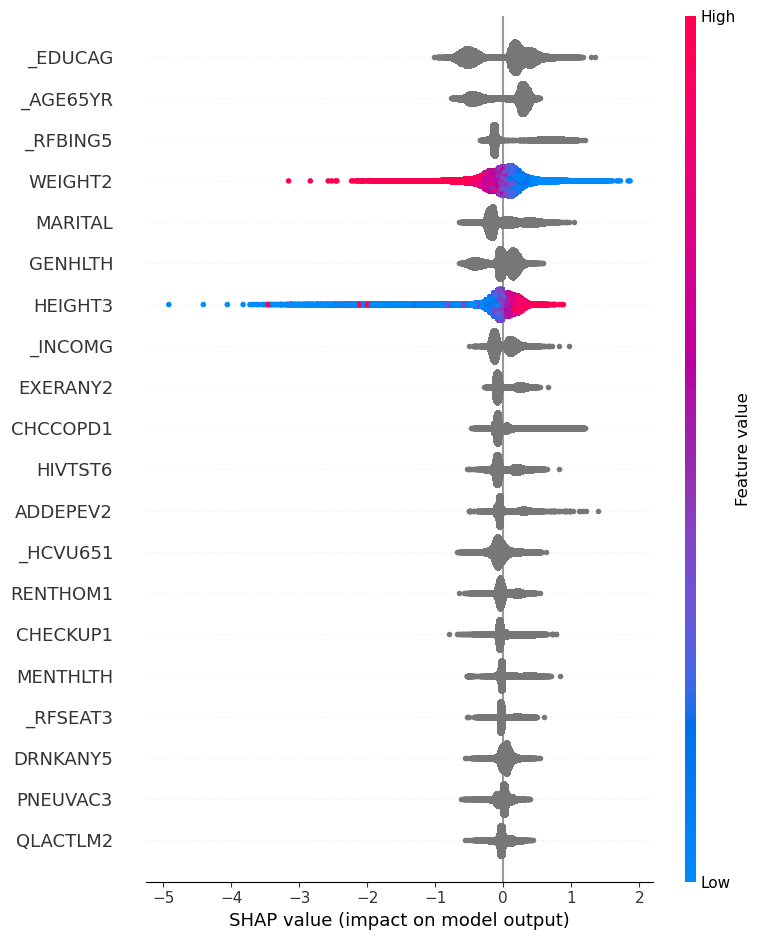

In [52]:
# Remove the last column (expected value) for plotting
shap_values_no_base = shap_values[:, :-1]

# Summary plot
shap.summary_plot(shap_values_no_base, X, feature_names=feature_names)

# Force plot for a single prediction
shap.force_plot(
    explainer.expected_value, 
    shap_values_no_base[0, :],  # exclude the extra column
    X.iloc[0, :],               # use pandas row
    feature_names=feature_names
)


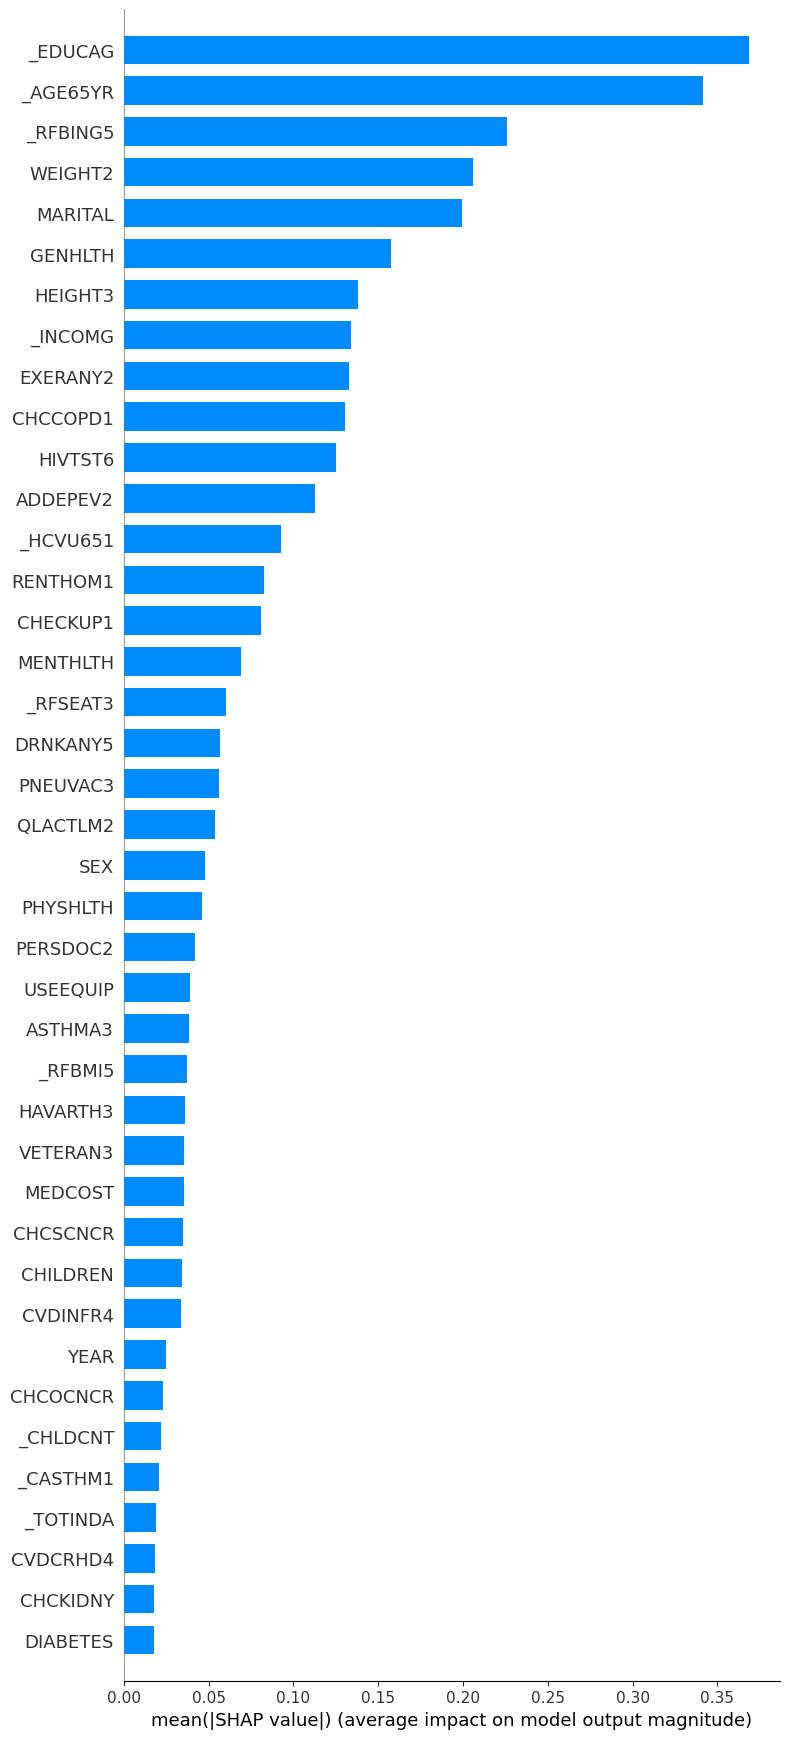

In [55]:

shap.summary_plot(shap_values_no_base, X, plot_type="bar", max_display=40)


## Building a RandomForest Model and evaluating impact of features

In [58]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
from imblearn.ensemble import BalancedRandomForestClassifier

# Load encoded data from data/modeling directory
with open('../data/modeling/data_splits_encoded.pkl', 'rb') as f:
    encoded_data = pickle.load(f)
    X_train_encoded = encoded_data['X_train']
    X_test_encoded = encoded_data['X_test']
    y_train_encoded = encoded_data['y_train']
    y_test_encoded = encoded_data['y_test']

# 1. Instantiate and train the Random Forest model
brf = BalancedRandomForestClassifier(random_state=42)
brf.fit(X_train_encoded, y_train_encoded)

# 2. Make predictions on the test set
y_pred = rf.predict(X_test_encoded)
y_pred_proba = rf.predict_proba(X_test_encoded)[:, 1] if len(np.unique(y_train_encoded)) == 2 else None

# 3. Evaluate model metrics
accuracy = accuracy_score(y_test_encoded, y_pred)
precision = precision_score(y_test_encoded, y_pred, average='binary' if len(np.unique(y_train_encoded)) == 2 else 'macro')
recall = recall_score(y_test_encoded, y_pred, average='binary' if len(np.unique(y_train_encoded)) == 2 else 'macro')
f1 = f1_score(y_test_encoded, y_pred, average='binary' if len(np.unique(y_train_encoded)) == 2 else 'macro')
roc_auc = roc_auc_score(y_test_encoded, y_pred_proba) if y_pred_proba is not None else None
cm = confusion_matrix(y_test_encoded, y_pred)
report = classification_report(y_test_encoded, y_pred)

# 4. Print results
print("Random Forest Model Evaluation Metrics:")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
if roc_auc is not None:
    print(f"ROC AUC:   {roc_auc:.4f}")
print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(report)

/opt/anaconda3/lib/python3.12/site-packages/imblearn/ensemble/_forest.py:577: FutureWarning: The default of `sampling_strategy` will change from `'auto'` to `'all'` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `'all'` to silence this warning and adopt the future behaviour.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/imblearn/ensemble/_forest.py:589: FutureWarning: The default of `replacement` will change from `False` to `True` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `True` to silence this warning and adopt the future behaviour.
  warn(
/opt/anaconda3/lib/python3.12/site-packages/imblearn/ensemble/_forest.py:601: FutureWarning: The default of `bootstrap` will change from `True` to `False` in version 0.13. This change will follow the implementation proposed in the original paper. Set to `False` to silence this warning and adopt the future behaviour.
  warn(


Random Forest Model Evaluation Metrics:
Accuracy:  0.8500
Precision: 0.6152
Recall:    0.1326
F1 Score:  0.2182
ROC AUC:   0.7712

Confusion Matrix:
[[383263   6054]
 [ 63308   9678]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.98      0.92    389317
           1       0.62      0.13      0.22     72986

    accuracy                           0.85    462303
   macro avg       0.74      0.56      0.57    462303
weighted avg       0.82      0.85      0.81    462303



We tried creating our base model using Random forest and observed that it has a low recall. It can be considered as a preliminary step before we proceed to evaluate complicated training models

## Plotting SHAP values by age group to identify important and relevant levers

/var/folders/m2/ycqz5h_d2y55049kl0cst9rm0000gn/T/ipykernel_61840/346726272.py:27: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_age = df[df_for_report['_AGE_G'] == age_code]


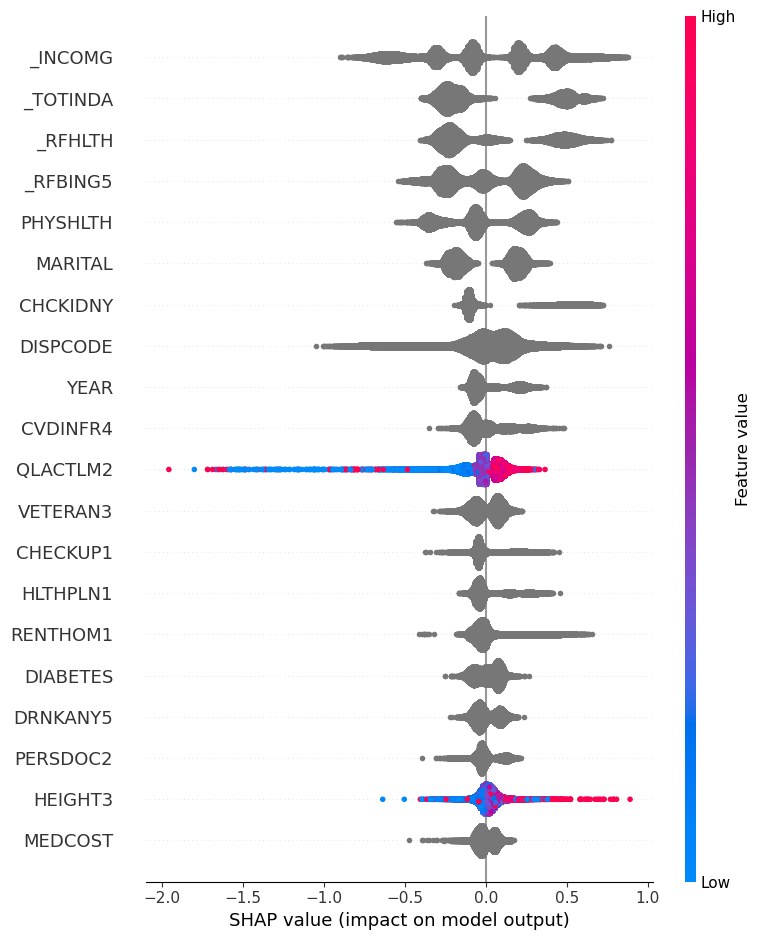

/var/folders/m2/ycqz5h_d2y55049kl0cst9rm0000gn/T/ipykernel_61840/346726272.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


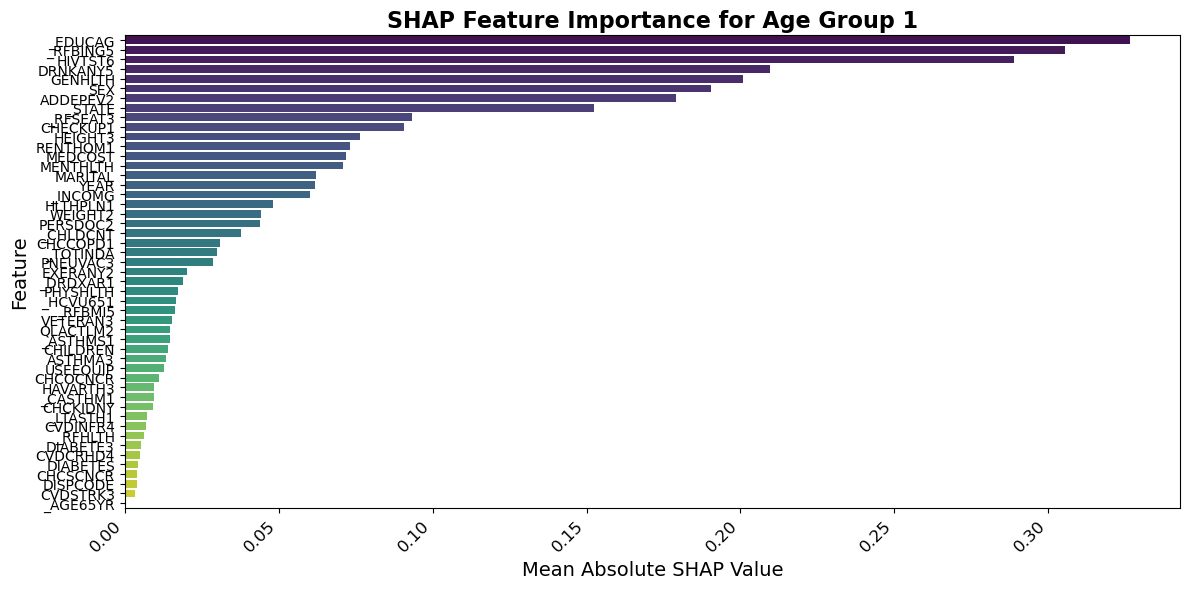

/var/folders/m2/ycqz5h_d2y55049kl0cst9rm0000gn/T/ipykernel_61840/346726272.py:27: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_age = df[df_for_report['_AGE_G'] == age_code]


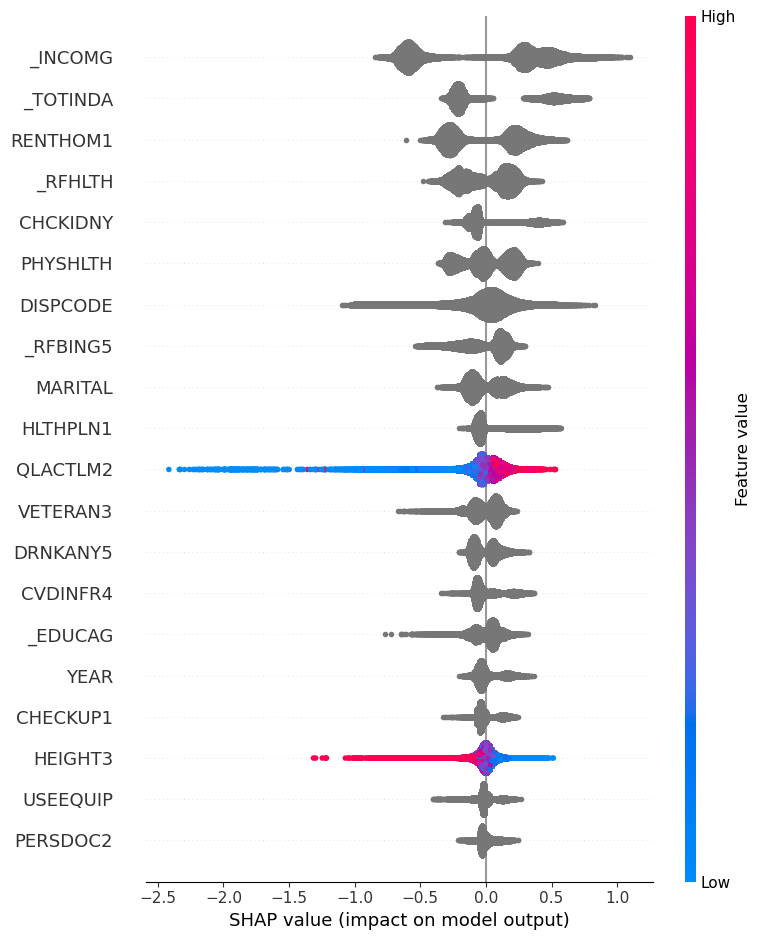

/var/folders/m2/ycqz5h_d2y55049kl0cst9rm0000gn/T/ipykernel_61840/346726272.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


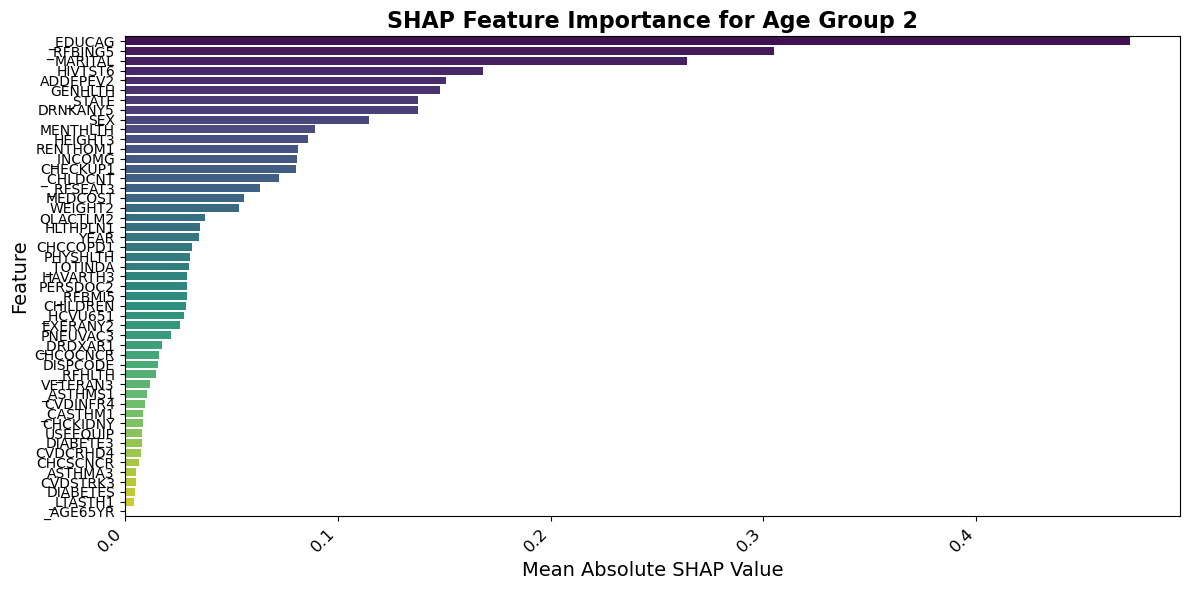

/var/folders/m2/ycqz5h_d2y55049kl0cst9rm0000gn/T/ipykernel_61840/346726272.py:27: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_age = df[df_for_report['_AGE_G'] == age_code]


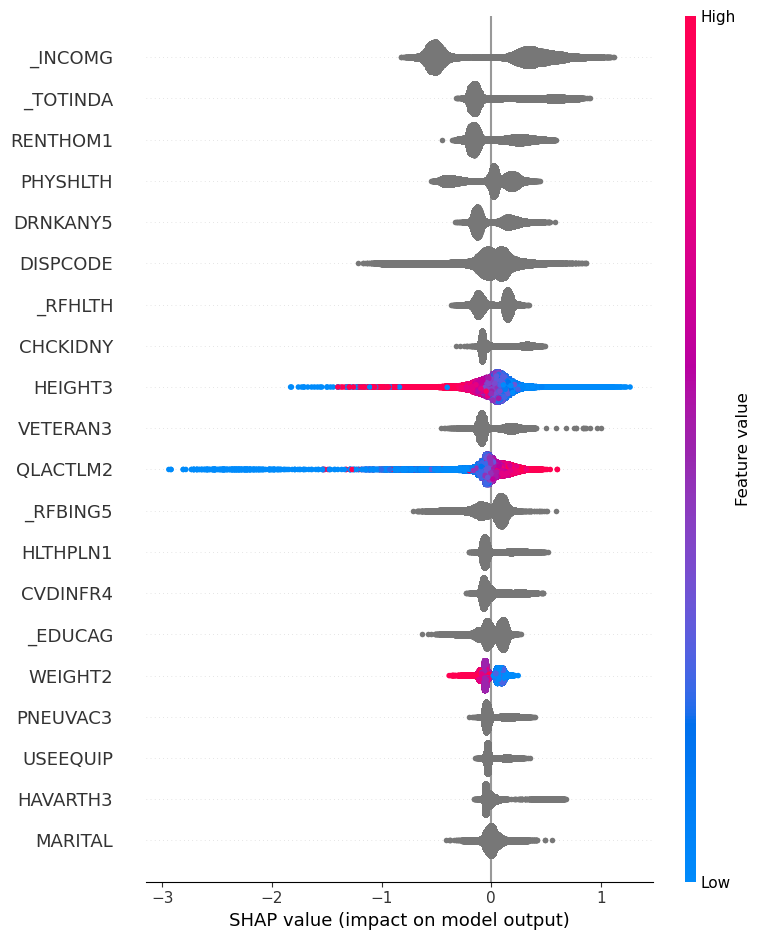

/var/folders/m2/ycqz5h_d2y55049kl0cst9rm0000gn/T/ipykernel_61840/346726272.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


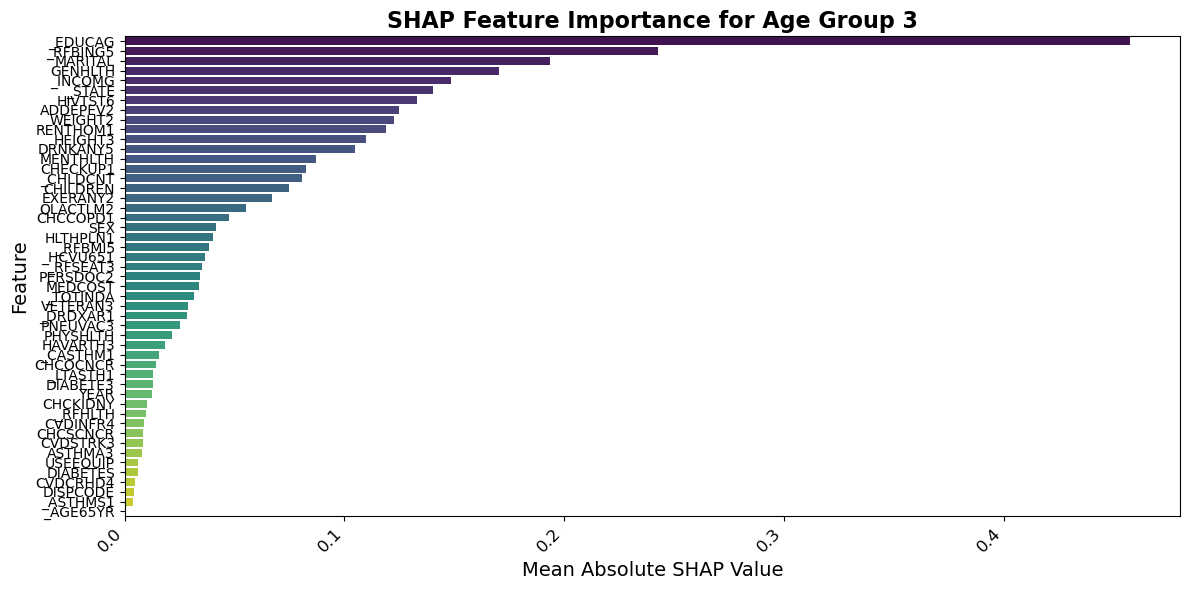

/var/folders/m2/ycqz5h_d2y55049kl0cst9rm0000gn/T/ipykernel_61840/346726272.py:27: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_age = df[df_for_report['_AGE_G'] == age_code]


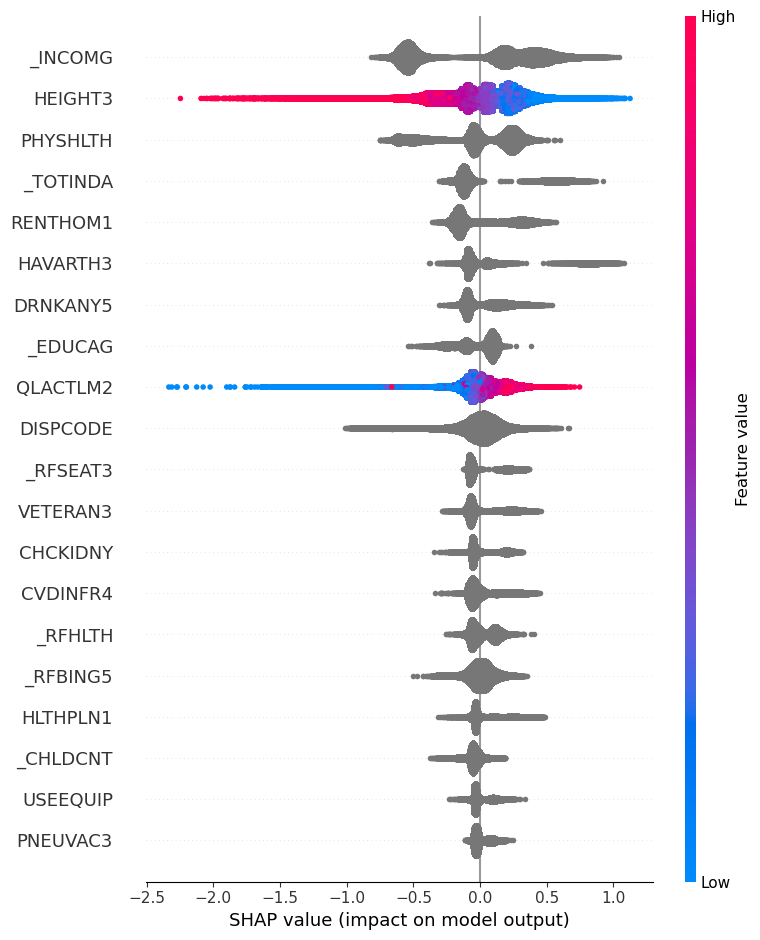

/var/folders/m2/ycqz5h_d2y55049kl0cst9rm0000gn/T/ipykernel_61840/346726272.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


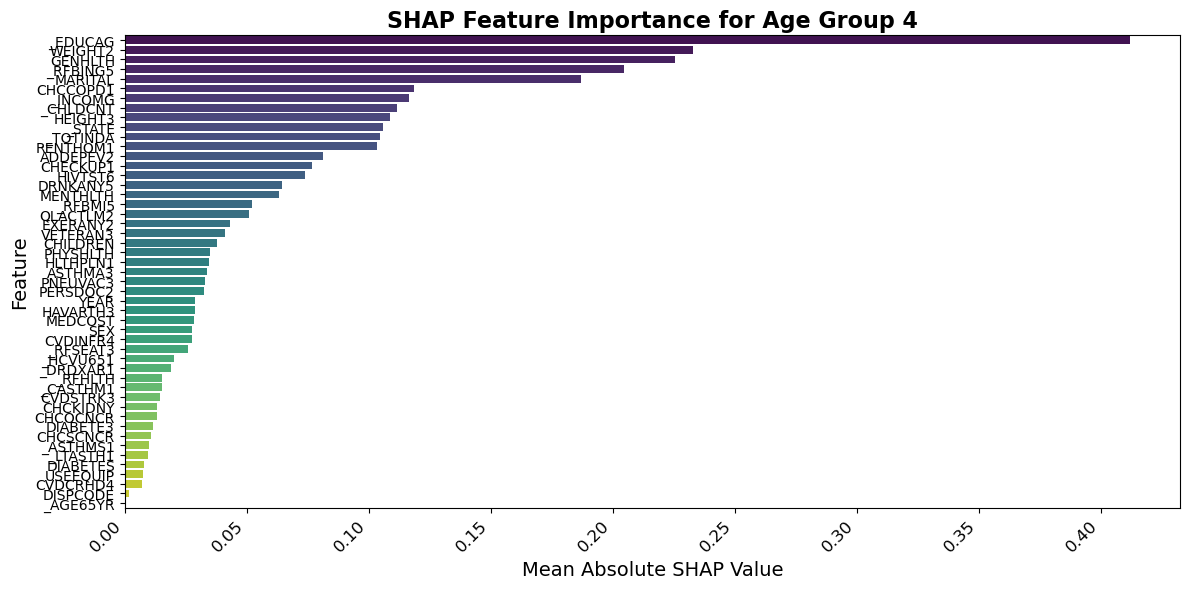

/var/folders/m2/ycqz5h_d2y55049kl0cst9rm0000gn/T/ipykernel_61840/346726272.py:27: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_age = df[df_for_report['_AGE_G'] == age_code]


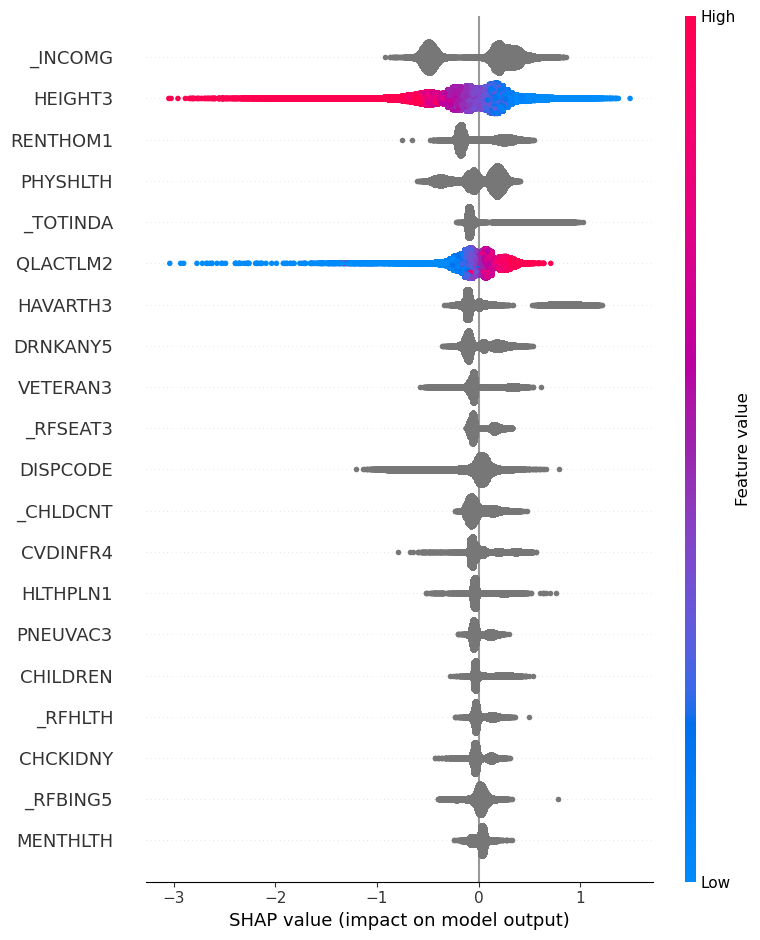

/var/folders/m2/ycqz5h_d2y55049kl0cst9rm0000gn/T/ipykernel_61840/346726272.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


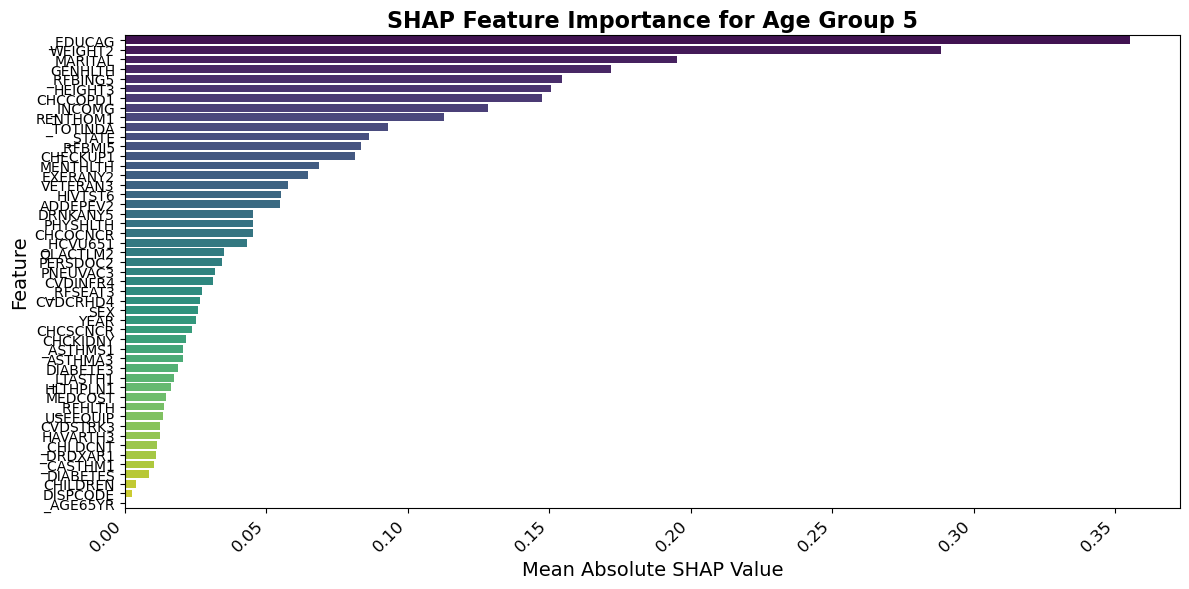

/var/folders/m2/ycqz5h_d2y55049kl0cst9rm0000gn/T/ipykernel_61840/346726272.py:27: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_age = df[df_for_report['_AGE_G'] == age_code]


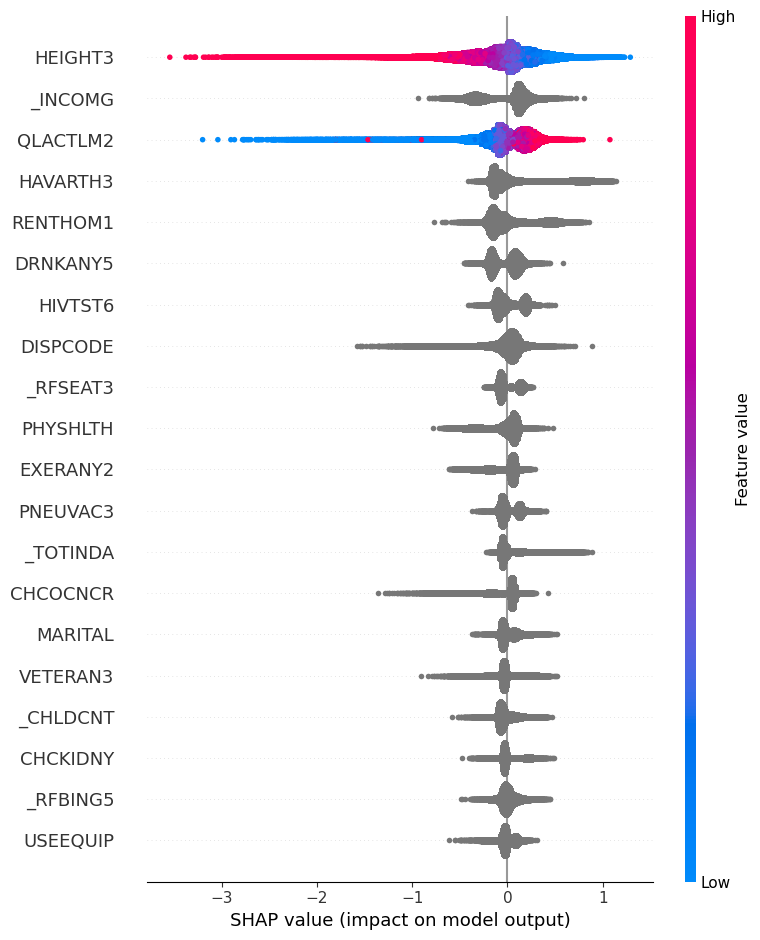

/var/folders/m2/ycqz5h_d2y55049kl0cst9rm0000gn/T/ipykernel_61840/346726272.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


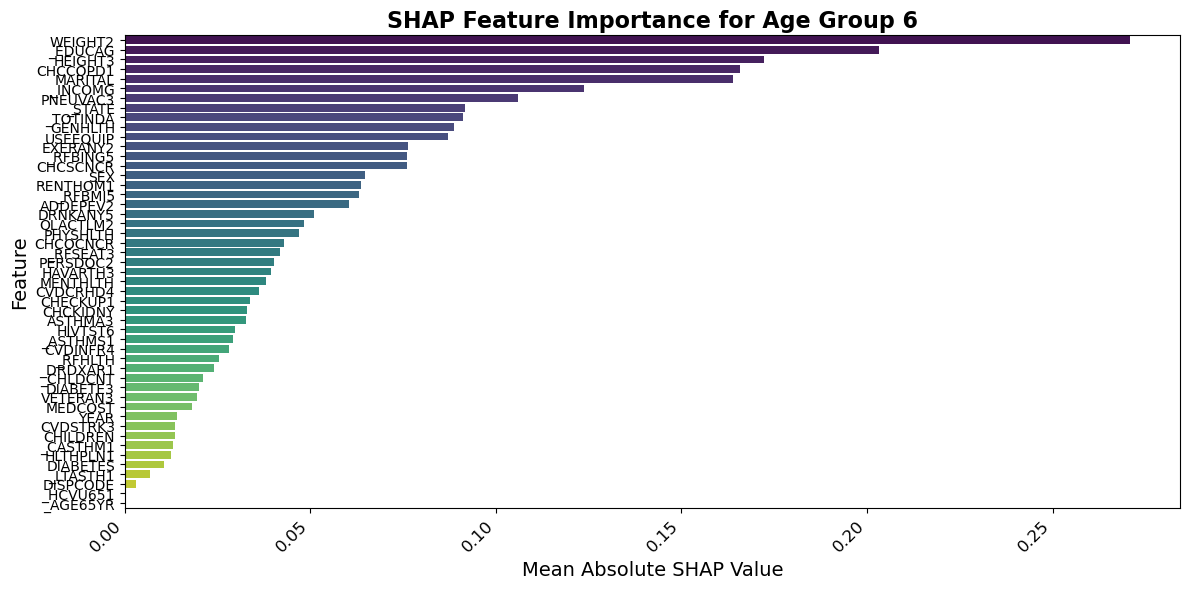

In [62]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from catboost import CatBoostClassifier  # or CatBoostRegressor as appropriate

from catboost import Pool

# Prepare
age_codes = df_for_report['_AGE_G'].cat.categories if hasattr(df_for_report['_AGE_G'], 'cat') else df_for_report['_AGE_G'].unique()
palette = sns.color_palette("husl", len(age_codes))
bubble_age_list = []

# Features to use (excluding target and _AGE_G)
feature_cols = [col for col in df.columns if col not in ['_RFSMOK3', '_AGE_G']]  # replace 'target' as needed

# From feature_cols, keep only categorical (object or category dtype)
catboost_categorical_columns = [
    col for col in feature_cols 
    if df[col].dtype == "object" or df[col].dtype.name == "category"
]

for col in catboost_categorical_columns:
    df[col] = df[col].astype(str).fillna('7')

for idx, age_code in enumerate(age_codes):
    # Subset data for this age group
    df_age = df[df_for_report['_AGE_G'] == age_code]
    X = df_age[feature_cols]
    y = df_age['_RFSMOK3']  # replace 'target' with your actual target variable

    # Skip if too few samples to train
    if len(df_age) < 10 or y.nunique() < 2:
        continue

    # Train CatBoost model
    model = CatBoostClassifier(verbose=0, random_state=42,auto_class_weights='Balanced',
    cat_features=catboost_categorical_columns)
    # Wrap your data in a Pool
    train_pool = Pool(data=X, label=y, cat_features=catboost_categorical_columns)
    # Training
    model.fit(train_pool)
    # Feature importance
    shap_values = model.get_feature_importance(train_pool,type='ShapValues')

    #agregate by HBM constructs by SHAP values
    # The first column is the expected value, so we take the mean absolute SHAP value
    shap_values_no_base = shap_values[:, :-1]
    # Summary plot
    shap.summary_plot(shap_values_no_base, X, feature_names=feature_names)

    # Force plot for a single prediction
    shap.force_plot(
        explainer.expected_value, 
        shap_values_no_base[0, :],  # exclude the extra column
        X.iloc[0, :],               # use pandas row
        feature_names=feature_names
    )


    shap_values_mean = np.abs(shap_values_no_base).mean(axis=0)
    # Create a Series for easier handling


    feature_importance_series = pd.Series(shap_values_mean, index=feature_cols)
    # feature_importance_series = pd.Series(importances, index=feature_cols)
    # feature_importance_series = pd.Series(importances, index=feature_cols)
    # feature_importance_series = pd.Series(importances, index=feature_cols)
    
    #plot the shap values for each age group
    plt.figure(figsize=(12, 6))  # wider figure helps spacing
    shap_values_sorted = feature_importance_series.sort_values(ascending=False)

    sns.barplot(
        x=shap_values_sorted.values, 
        y=shap_values_sorted.index, 
        palette="viridis"
    )

    plt.title(f'SHAP Feature Importance for Age Group {age_code}', fontsize=16, weight='bold')
    plt.xlabel('Mean Absolute SHAP Value', fontsize=14)
    plt.ylabel('Feature', fontsize=14)

    # Fix overlapping x-axis labels
    plt.xticks(rotation=45, ha='right')   # tilt labels
    plt.tick_params(axis='x', labelsize=12)  # bigger, readable ticks

    plt.tight_layout()
    plt.show()


    #save the model for each age group
    model.save_model(f'../models/catboost_model_age_{age_code}.cbm')
